In [1]:
import pandas as pd

df = pd.read_csv("Data/ai4i_predictive_maintenance.csv")

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,L70598,L,297.9,307.1,1525,20.3,238,0,0,0,0,0,0
1,2,H76399,H,298.6,307.8,1384,32.3,249,0,0,0,0,0,0
2,3,M37684,M,305.0,314.1,1958,36.3,67,0,0,0,0,0,0
3,4,L78591,L,300.3,309.7,1009,46.8,248,1,0,0,0,1,0
4,5,L87722,L,300.7,311.6,1863,38.6,133,0,0,0,0,0,0


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

In [3]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='str')

In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 10000
Columns: 14


In [5]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [6]:
failure_rate = df['Machine failure'].mean() * 100

print("Failure Rate:", round(failure_rate,2), "%")

Failure Rate: 6.38 %


In [7]:
failures = df['Machine failure'].sum()

cost_per_failure = 50000

total_loss = failures * cost_per_failure

print("Total Failures:", failures)
print("Estimated Financial Loss: ₹", format(total_loss, ","))

Total Failures: 638
Estimated Financial Loss: ₹ 31,900,000


In [8]:
df.groupby('Type')['Machine failure'].mean()*100

Type
H    4.890739
L    7.498363
M    4.537700
Name: Machine failure, dtype: float64

In [9]:
failure_causes = {
    'Tool Wear Failure': df['TWF'].sum(),
    'Heat Dissipation Failure': df['HDF'].sum(),
    'Power Failure': df['PWF'].sum(),
    'Overstrain Failure': df['OSF'].sum(),
    'Random Failure': df['RNF'].sum()
}

failure_causes

{'Tool Wear Failure': np.int64(154),
 'Heat Dissipation Failure': np.int64(158),
 'Power Failure': np.int64(22),
 'Overstrain Failure': np.int64(339),
 'Random Failure': np.int64(10)}

In [10]:
df.groupby('Type')['Machine failure'].mean()*100

Type
H    4.890739
L    7.498363
M    4.537700
Name: Machine failure, dtype: float64

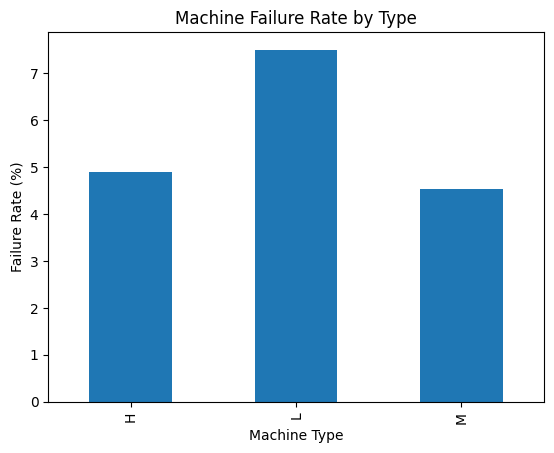

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

failure_by_type = df.groupby('Type')['Machine failure'].mean()*100

failure_by_type.plot(kind='bar')

plt.title("Machine Failure Rate by Type")
plt.ylabel("Failure Rate (%)")
plt.xlabel("Machine Type")

plt.show()

In [12]:
failure_causes = {
    'Tool Wear Failure': df['TWF'].sum(),
    'Heat Dissipation Failure': df['HDF'].sum(),
    'Power Failure': df['PWF'].sum(),
    'Overstrain Failure': df['OSF'].sum(),
    'Random Failure': df['RNF'].sum()
}

failure_causes

{'Tool Wear Failure': np.int64(154),
 'Heat Dissipation Failure': np.int64(158),
 'Power Failure': np.int64(22),
 'Overstrain Failure': np.int64(339),
 'Random Failure': np.int64(10)}

In [13]:
df.groupby('Machine failure')['Tool wear [min]'].mean()

Machine failure
0    119.16097
1    196.26489
Name: Tool wear [min], dtype: float64

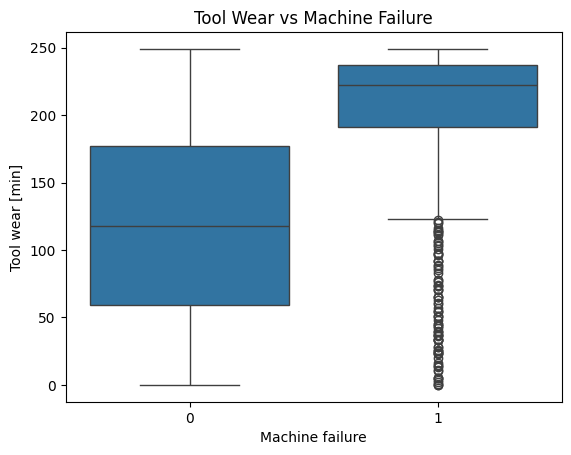

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    x='Machine failure',
    y='Tool wear [min]',
    data=df
)

plt.title("Tool Wear vs Machine Failure")
plt.show()

In [15]:
(196.26-119.16)/119.16 * 100

64.7029204431017

In [16]:
df.groupby('Machine failure')['Torque [Nm]'].mean()

Machine failure
0    39.388539
1    47.556426
Name: Torque [Nm], dtype: float64

In [17]:
df.groupby('Machine failure')['Air temperature [K]'].mean()

Machine failure
0    300.017026
1    300.024922
Name: Air temperature [K], dtype: float64

In [18]:
df.groupby('Machine failure')['Process temperature [K]'].mean()

Machine failure
0    310.038347
1    309.613166
Name: Process temperature [K], dtype: float64

In [19]:
df['Tool wear [min]'].describe()

count    10000.000000
mean       124.080200
std         72.063675
min          0.000000
25%         62.000000
50%        124.000000
75%        186.000000
max        249.000000
Name: Tool wear [min], dtype: float64

In [20]:
df['Torque [Nm]'].describe()

count    10000.000000
mean        39.909650
std          9.926393
min          2.900000
25%         33.300000
50%         40.000000
75%         46.600000
max         77.200000
Name: Torque [Nm], dtype: float64

In [21]:
def recommend_action(row):

    if row['Tool wear [min]'] > 186:
        return "Replace Tool Immediately"

    elif row['Torque [Nm]'] > 46.6:
        return "Reduce Machine Load"

    else:
        return "Continue Monitoring"

In [22]:
df['Recommendation'] = df.apply(recommend_action, axis=1)

df[['Tool wear [min]',
    'Torque [Nm]',
    'Recommendation']].head(10)

,Tool wear [min],Torque [Nm],Recommendation
0,238,20.3,Replace Tool Immediately
1,249,32.3,Replace Tool Immediately
2,67,36.3,Continue Monitoring
3,248,46.8,Replace Tool Immediately
4,133,38.6,Continue Monitoring
5,121,50.5,Reduce Machine Load
6,210,45.9,Replace Tool Immediately
7,59,45.0,Continue Monitoring
8,218,49.7,Replace Tool Immediately
9,243,26.1,Replace Tool Immediately


In [23]:
df['Recommendation'].value_counts()

Recommendation
Continue Monitoring         5679
Replace Tool Immediately    2481
Reduce Machine Load         1840
Name: count, dtype: int64

In [24]:
def calculate_risk(row):

    risk = 0

    if row['Tool wear [min]'] > 186:
        risk += 50

    if row['Torque [Nm]'] > 46.6:
        risk += 50

    return risk

In [25]:
df['Risk Score'] = df.apply(calculate_risk, axis=1)

df[['Tool wear [min]',
    'Torque [Nm]',
    'Risk Score']].head(10)

,Tool wear [min],Torque [Nm],Risk Score
0,238,20.3,50
1,249,32.3,50
2,67,36.3,0
3,248,46.8,100
4,133,38.6,0
5,121,50.5,50
6,210,45.9,50
7,59,45.0,0
8,218,49.7,100
9,243,26.1,50


In [26]:
df['Risk Score'].value_counts()

Risk Score
0      5679
50     3684
100     637
Name: count, dtype: int64

In [27]:
current_loss = 31900000

print("15% Reduction Savings: ₹", format(current_loss*0.15, ",.0f"))
print("20% Reduction Savings: ₹", format(current_loss*0.20, ",.0f"))
print("30% Reduction Savings: ₹", format(current_loss*0.30, ",.0f"))

15% Reduction Savings: ₹ 4,785,000
20% Reduction Savings: ₹ 6,380,000
30% Reduction Savings: ₹ 9,570,000


In [28]:
def risk_category(score):

    if score == 100:
        return "High Risk"

    elif score == 50:
        return "Medium Risk"

    else:
        return "Low Risk"

In [29]:
df['Risk Category'] = df['Risk Score'].apply(risk_category)

df['Risk Category'].value_counts()

Risk Category
Low Risk       5679
Medium Risk    3684
High Risk       637
Name: count, dtype: int64

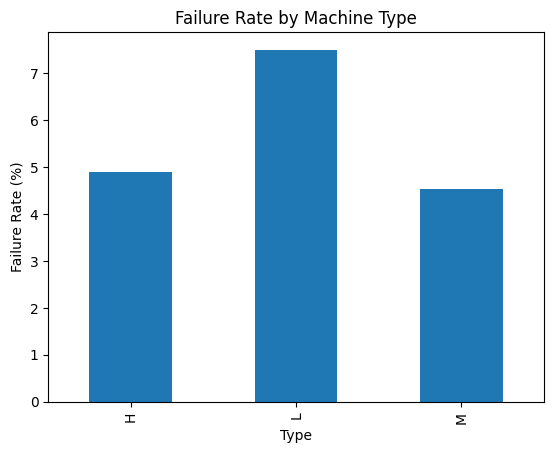

In [30]:
failure_by_type = df.groupby('Type')['Machine failure'].mean()*100

failure_by_type.plot(kind='bar')
plt.title("Failure Rate by Machine Type")
plt.ylabel("Failure Rate (%)")
plt.show()

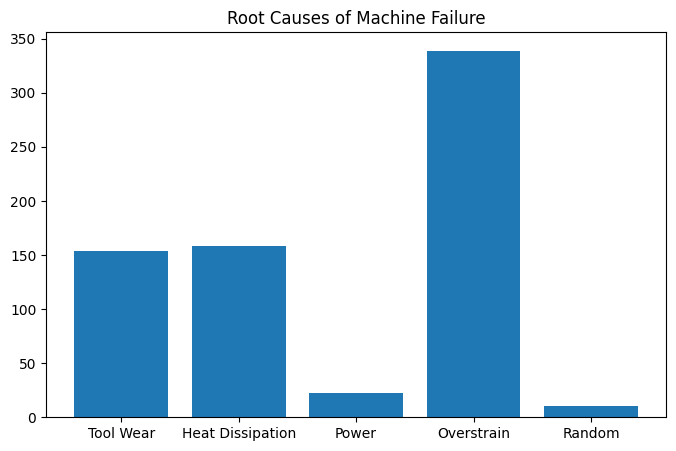

In [31]:
failure_causes = {
    'Tool Wear':154,
    'Heat Dissipation':158,
    'Power':22,
    'Overstrain':339,
    'Random':10
}

plt.figure(figsize=(8,5))
plt.bar(failure_causes.keys(), failure_causes.values())
plt.title("Root Causes of Machine Failure")
plt.show()

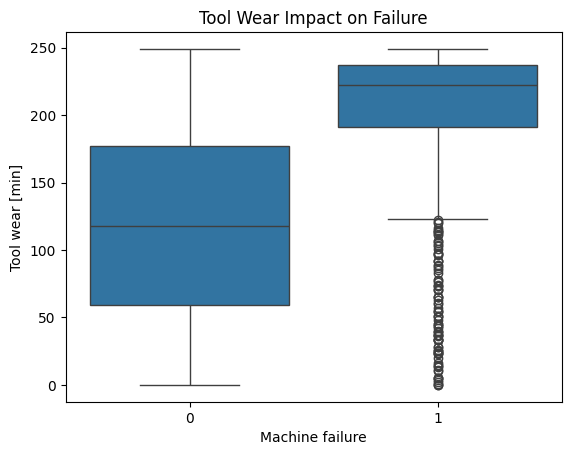

In [32]:
sns.boxplot(
    x='Machine failure',
    y='Tool wear [min]',
    data=df
)

plt.title("Tool Wear Impact on Failure")
plt.show()

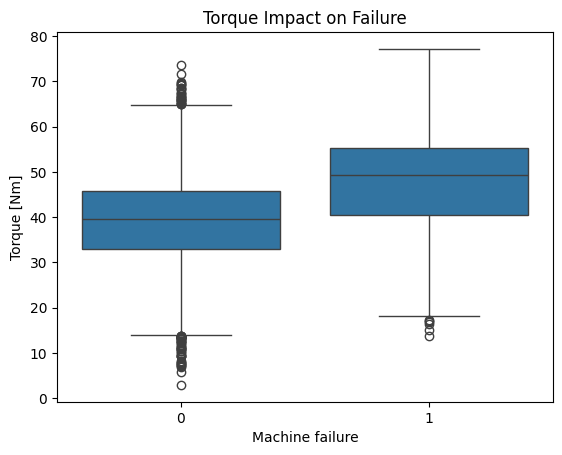

In [33]:
sns.boxplot(
    x='Machine failure',
    y='Torque [Nm]',
    data=df
)

plt.title("Torque Impact on Failure")
plt.show()

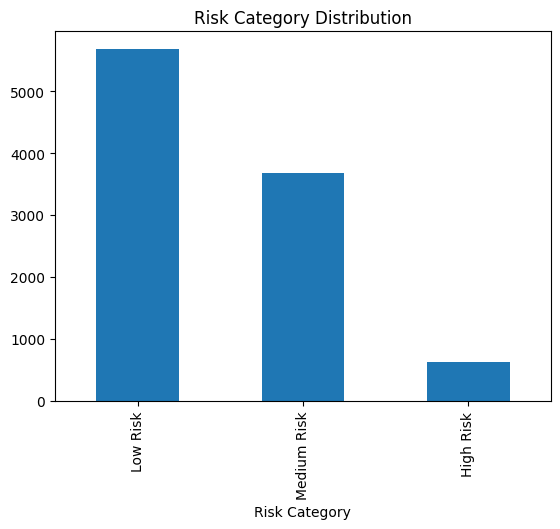

In [34]:
df['Risk Category'].value_counts().plot(kind='bar')

plt.title("Risk Category Distribution")
plt.show()

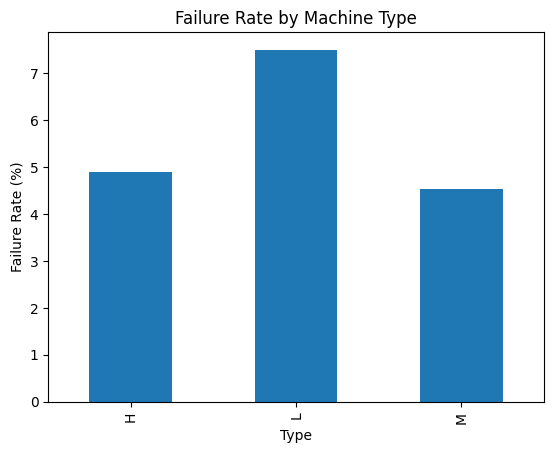

In [35]:
failure_by_type.plot(kind='bar')

plt.title("Failure Rate by Machine Type")
plt.ylabel("Failure Rate (%)")

plt.savefig("images/failure_rate_by_type.png")

plt.show()

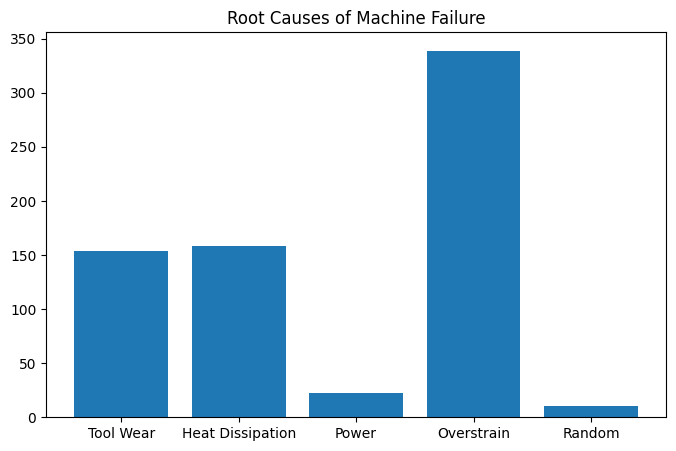

In [36]:
plt.figure(figsize=(8,5))
plt.bar(failure_causes.keys(), failure_causes.values())
plt.title("Root Causes of Machine Failure")

plt.savefig("images/root_causes.png")

plt.show()

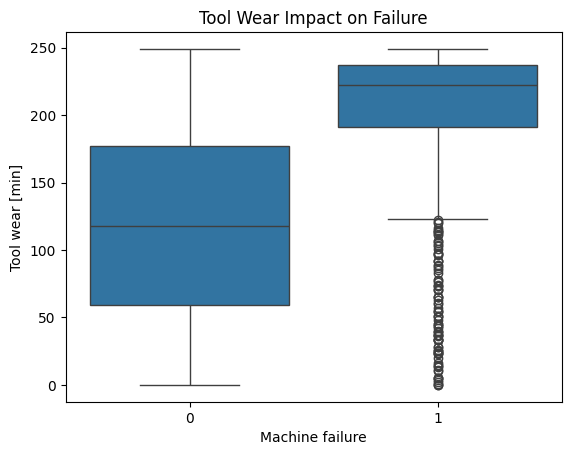

In [37]:
sns.boxplot(
    x='Machine failure',
    y='Tool wear [min]',
    data=df
)

plt.title("Tool Wear Impact on Failure")

plt.savefig("images/tool_wear_vs_failure.png")

plt.show()

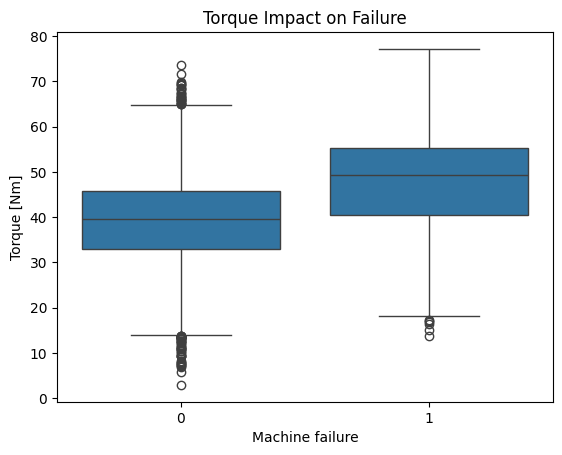

In [38]:
sns.boxplot(
    x='Machine failure',
    y='Torque [Nm]',
    data=df
)

plt.title("Torque Impact on Failure")

plt.savefig("images/torque_vs_failure.png")

plt.show()

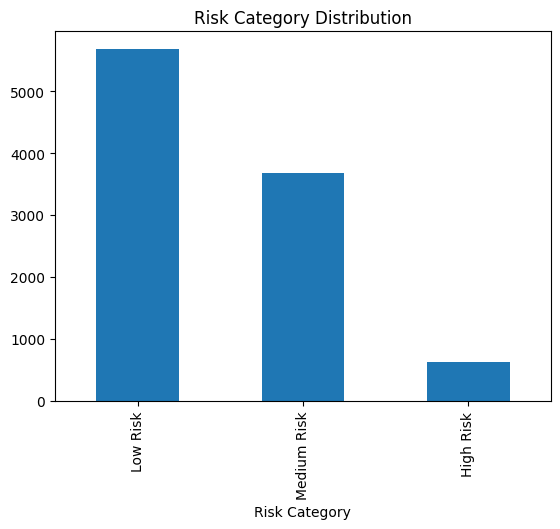

In [39]:
df['Risk Category'].value_counts().plot(kind='bar')

plt.title("Risk Category Distribution")

plt.savefig("images/risk_category_distribution.png")

plt.show()

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [41]:
X = df[
    [
        'Air temperature [K]',
        'Process temperature [K]',
        'Rotational speed [rpm]',
        'Torque [Nm]',
        'Tool wear [min]'
    ]
]

y = df['Machine failure']

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [43]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [44]:
y_pred = model.predict(X_test)

In [45]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy*100,2), "%")

Accuracy: 96.45 %


In [46]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1863
           1       0.88      0.56      0.68       137

    accuracy                           0.96      2000
   macro avg       0.92      0.78      0.83      2000
weighted avg       0.96      0.96      0.96      2000



In [47]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance.sort_values(
    by='Importance',
    ascending=False
)

,Feature,Importance
4,Tool wear [min],0.300889
3,Torque [Nm],0.295951
2,Rotational speed [rpm],0.140555
0,Air temperature [K],0.132764
1,Process temperature [K],0.129840
